# PoissonVAE

Reimplements the core model from [hadivafaii/PoissonVAE](https://github.com/hadivafaii/PoissonVAE)
(paper: https://arxiv.org/pdf/2405.14473), mirroring the structure of `vae.ipynb` /
`svae.ipynb` (data → model → train → sample → reconstructions → interpolations).

The official repo is a full research codebase (wandb logging, disk-writing configs, a
custom NAS-style layer library) and is not pip-installable, so instead of importing it
directly this notebook ports its two load-bearing pieces — the reparameterized `Poisson`
distribution and the closed-form Poisson KL — verbatim from `base/distributions.py` and
`main/vae.py`, wired into a small linear encoder/decoder VAE analogous to the baseline
used elsewhere in this survey.

In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"

## Data

Same MNIST split used by `vae.ipynb`. PoissonVAE keeps pixels in `[0, 1]` (no mean/std normalization), consistent with treating pixel intensity as a rate-like quantity.

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

train_dataset = mnist_trainset.data[:-10000].reshape(-1, 1, 28, 28) / 255.
eval_dataset = mnist_trainset.data[-10000:].reshape(-1, 1, 28, 28) / 255.

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.33MB/s]


## Poisson distribution

Ported from `base/distributions.py::Poisson`. Sampling uses a temperature-relaxed thinning
of a Poisson process: exponential inter-arrival times are cumulatively summed into arrival
times, and a sigmoid soft-thresholds each arrival against `t=1` to produce a differentiable
"spike count". At `temp=0` this collapses to a true (non-differentiable) `torch.poisson` draw,
which is what the official repo uses at generation/inference time.

In [3]:
class Poisson:
    def __init__(self, log_rate, temp=0.0, n_exp=64, eps=1e-6):
        self.log_rate = log_rate
        self.rate = torch.exp(log_rate) + eps
        self.temp = temp
        self.n_exp = n_exp
        self._exp = torch.distributions.Exponential(self.rate)

    def rsample(self):
        if self.temp == 0.0:
            return self.sample()
        x = self._exp.rsample((self.n_exp,))
        times = torch.cumsum(x, dim=0)
        logits = (1 - times) / self.temp
        indicator = torch.sigmoid(logits)
        z = indicator.sum(0)
        return z

    def sample(self):
        return torch.poisson(self.rate)

    @property
    def mean(self):
        return self.rate

## Model

A linear encoder/decoder PoissonVAE, matching the `enc_type='lin', dec_type='lin'` config
used for MNIST in the official repo's `default_configs('MNIST', 'poisson', 'lin|lin')`. The
encoder outputs a log-rate-ratio per latent (`log_dr`); the prior log-rate (`log_rate`) is a
learned parameter shared across the batch (`fit_prior=True` in the original).

In [4]:
class PoissonVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, n_latents=64, n_exp=64):
        super().__init__()
        self.n_latents = n_latents
        self.n_exp = n_exp

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_latents),
        )
        self.decoder = nn.Sequential(
            nn.Linear(n_latents, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )
        # learned prior log-rate, shared across the batch
        self.log_rate = nn.Parameter(torch.zeros(n_latents))

    def infer(self, x, temp=1.0):
        log_dr = self.encoder(x.view(x.size(0), -1))
        log_r = self.log_rate.expand(len(log_dr), -1) + log_dr
        dist = Poisson(log_r, temp=temp, n_exp=self.n_exp)
        return dist, log_dr

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x, temp=1.0):
        dist, log_dr = self.infer(x, temp=temp)
        spks = dist.rsample()
        y = self.decode(spks)
        return y, spks, log_dr

    def loss_kl(self, log_dr):
        log_r = self.log_rate.expand(len(log_dr), -1)
        f = 1 + torch.exp(log_dr) * (log_dr - 1)
        return torch.exp(log_r) * f

    @torch.no_grad()
    def sample(self, n, temp=0.0):
        log_r = self.log_rate.expand(n, -1)
        dist = Poisson(log_r, temp=temp, n_exp=self.n_exp)
        spks = dist.rsample()
        return self.decode(spks), spks

## Training

Loss follows `PoissonVAE.loss_kl` / `TrainerVAE`: summed-pixel MSE reconstruction plus a
KL-beta-weighted Poisson KL, with `beta` linearly annealed from 0 to 1 over training (the
official repo also anneals `temp` from 1.0 down to ~0.05; we anneal `temp` linearly to a
smaller-but-nonzero floor for the same soft-to-hard-spike effect while keeping this cell
self-contained).

In [5]:
model = PoissonVAE(input_dim=784, hidden_dim=512, n_latents=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

num_epochs = 10  # Change this to train the model a bit more
batch_size = 100
temp_start, temp_stop = 1.0, 0.1

train_x = train_dataset.float().to(device)
n_batches = len(train_x) // batch_size

for epoch in range(num_epochs):
    perm = torch.randperm(len(train_x))
    epoch_loss = 0.0
    for step in range(n_batches):
        idx = perm[step * batch_size:(step + 1) * batch_size]
        x = train_x[idx]

        progress = (epoch * n_batches + step) / (num_epochs * n_batches)
        beta = min(1.0, progress * 2)
        temp = temp_start + (temp_stop - temp_start) * progress

        y, spks, log_dr = model(x, temp=temp)
        recon = nn.functional.mse_loss(y, x, reduction='sum') / len(x)
        kl = model.loss_kl(log_dr).sum(dim=1).mean()
        loss = recon + beta * kl

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"epoch {epoch + 1}/{num_epochs}  loss={epoch_loss / n_batches:.4f}")

epoch 1/10  loss=27.8949
epoch 2/10  loss=22.9592
epoch 3/10  loss=25.5367
epoch 4/10  loss=28.3032
epoch 5/10  loss=30.9832
epoch 6/10  loss=32.7325
epoch 7/10  loss=33.6250
epoch 8/10  loss=34.6876
epoch 9/10  loss=35.7184
epoch 10/10  loss=36.8864


## Visualizing samples

Unconditional samples drawn from the learned prior rate (`temp=0`, i.e. a true Poisson draw), analogous to the `NormalSampler` cells in `vae.ipynb`.

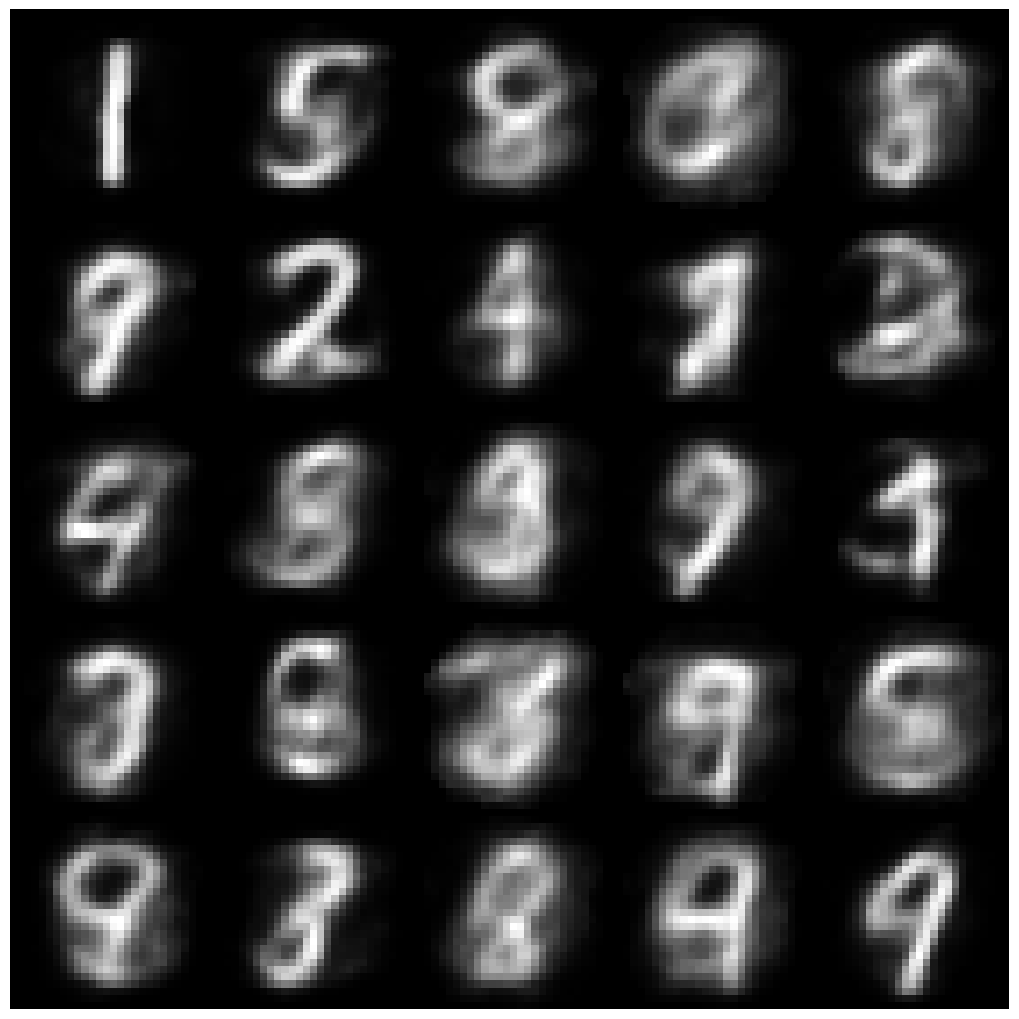

In [6]:
import matplotlib.pyplot as plt

model.eval()
gen_data, _ = model.sample(n=25, temp=0.0)
gen_data = gen_data.detach().cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j].squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

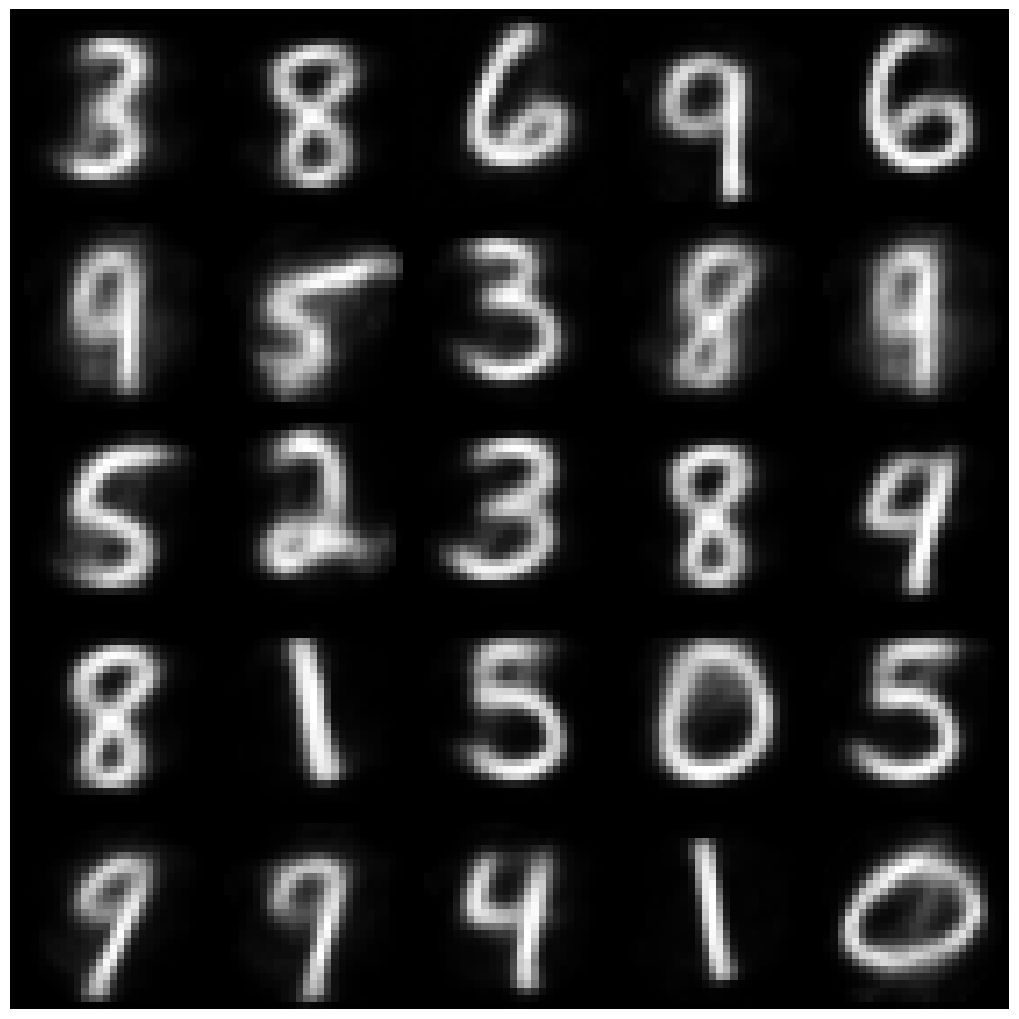

In [7]:
eval_x = eval_dataset[:25].float().to(device)
with torch.no_grad():
    dist, _ = model.infer(eval_x, temp=0.0)
    reconstructions = model.decode(dist.mean).detach().cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j].squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

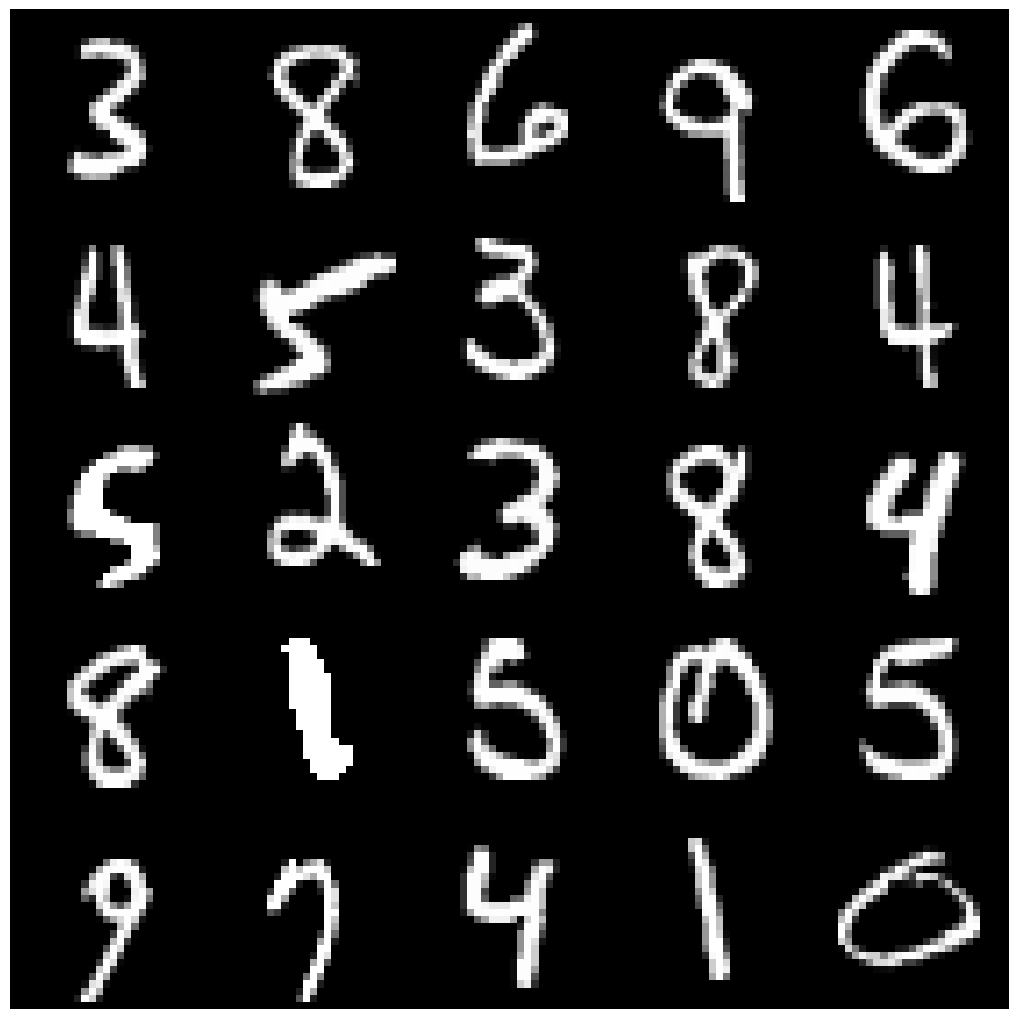

In [8]:
# show the true data
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(eval_dataset[i * 5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

The official repo has no built-in interpolation utility (its `interpolate`-adjacent code is
image-resize interpolation, unrelated to latent space). Since PoissonVAE latents are
nonnegative "spike counts"/rates, linear interpolation between the two posterior means is the
natural analogue of the Gaussian-latent interpolation used in `vae.ipynb`.

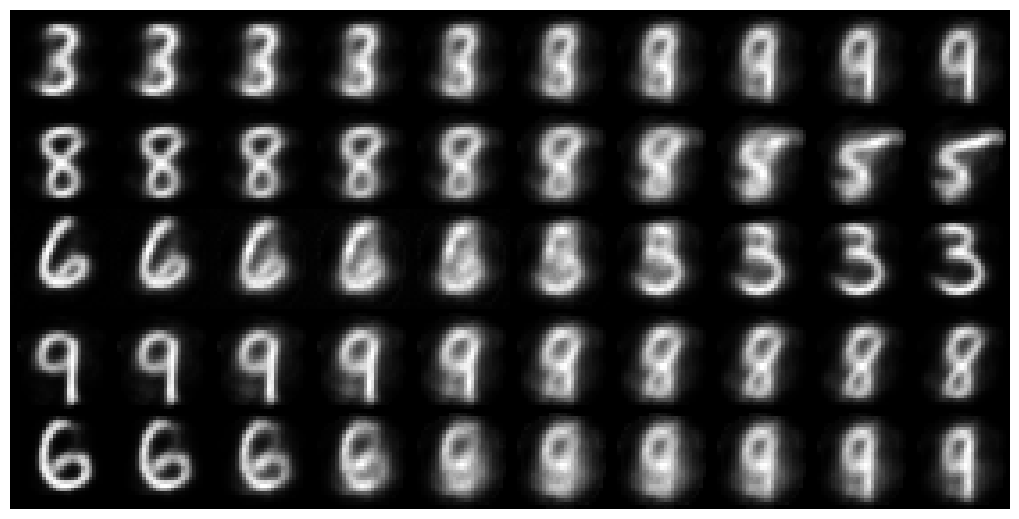

In [9]:
x1 = eval_dataset[:5].float().to(device)
x2 = eval_dataset[5:10].float().to(device)

with torch.no_grad():
    z1 = model.infer(x1, temp=0.0)[0].mean
    z2 = model.infer(x2, temp=0.0)[0].mean

    granularity = 10
    alphas = torch.linspace(0, 1, granularity, device=device).view(-1, 1, 1)
    z_interp = (1 - alphas) * z1 + alphas * z2  # (granularity, 5, n_latents)
    interpolations = model.decode(z_interp.reshape(-1, z1.size(-1)))
    interpolations = interpolations.view(granularity, 5, 1, 28, 28).permute(1, 0, 2, 3, 4).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j].squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)